# CNN. Frogs Classification

### Install dependencies manually

```bash
./bash/install.sh
```

### Change directory: project root

In [1]:
import os
from pathlib import Path

# Найти корень через поиск dvc.yaml
cwd = Path.cwd()
root = cwd
while not (root / "dvc.yaml").exists() and root != root.parent:
    root = root.parent

os.chdir(root)
print(root)

/home/user/Desktop/cnn-frogs


### Optional: clear data

In [2]:
%%script true

!python3 ../download/clear_data.py

| Команда | |
|---------------------|-----------------------------|
| `dvc repro` | весь pipeline |
| `dvc repro --force` | весь pipeline принудительно |
| `dvc repro stage` | запуск стадии "stage" |

### DVC repro

In [3]:
import subprocess
subprocess.run(["dvc", "repro"], cwd="/home/user/Desktop/cnn-frogs")

Stage 'get_links' didn't change, skipping
Stage 'get_imgs' didn't change, skipping
Data and pipelines are up to date.


CompletedProcess(args=['dvc', 'repro'], returncode=0)

### Optional: commit changes to remote DVC storage

In [4]:
%%script true

!dvc push

## CNN

### Import

In [5]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

### Constants

In [9]:
DATASET_PATH = 'download/dataset/'

CLASS_NAMES = [
    'Agalychnis_callidryas',
    'Breviceps_gibbosus',
    'Ceratophrys_cornuta',
    'Dendrobates_tinctorius',
    'Hyalinobatrachium_fleischmanni'
]

NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

### Transform

In [ ]:
# normalize: -> tensor -> [-1, 1]
#  speedup cnn convergence

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),         # -> тензор PyTorch [0, 1]
    transforms.Normalize(          # -> [-1, 1]
        # центрирование
        mean=[0.5, 0.5, 0.5],
        # масштабирование
        std=[0.5, 0.5, 0.5]
    )
    ## output = (input / 255 - 0.5) / 0.5
])

### Load Data

In [10]:
# Load dataset/
#  ImageFolder ожидает: dataset/class_name/image.jpg
full_dataset = torchvision.datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

# 0.8 + 0.2
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, test_size]
)

# DataLoader идет по батчам
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, # Stochastic
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, # Перемешивать для оценки не надо
    num_workers=2
)

print(f'Dataset size ... {len(full_dataset)}')
print(f'Train size ..... {len(train_dataset)}')
print(f'Test size ...... {len(test_dataset)}')
print(f'Classes ........ {full_dataset.classes}')

Dataset size ... 3974
Train size ..... 3179
Test size ...... 795
Classes ........ ['Agalychnis_callidryas', 'Breviceps_gibbosus', 'Ceratophrys_cornuta', 'Dendrobates_tinctorius', 'Hyalinobatrachium_fleischmanni']


### Model Architecture

In [ ]:
class FrogCNN(nn.Module):

    def __init__(self, num_classes):
        super(FrogCNN, self).__init__()
        
        # свёрточные слои -> признаки
        self.conv1 = nn.Conv2d( 3, 16, kernel_size=3, padding=1)  # 3 канала RGB -> 16 фильтров
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 фильтра
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64 фильтров
        
        # 2x2 -> в 4 раза меньше пикселей
        self.pool = nn.MaxPool2d(2, 2)
        
        # dropout предотвращает переобучение
        self.dropout = nn.Dropout(0.5)
        ## - на каждом шаге: случайные 1/2 нейронов обнуляются
        ## - остальные умножаются на 2
        ## - во время теста все нейроны активны, выход умножается на 0.5
        
        # fully-connected layers -> классификация
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # get features: conv -> relu -> pool
        x = self.pool(F.relu(self.conv1(x)))  # 64x64 -> 32x32
        x = self.pool(F.relu(self.conv2(x)))  # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv3(x)))  # 16x16 -> 08x08
        
        # flatten
        x = torch.flatten(x, 1) # 8x8x64 -> 4096
        
        # fully-connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

model = FrogCNN(NUM_CLASSES)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params ....... {total_params:,}')
print(f'Trainable params ... {trainable_params:,}')

FrogCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=5, bias=True)
)
Total params ....... 1,105,957
Trainable params ... 1,105,957


### Training

In [12]:
# -log(softmax(p0))
loss_function = nn.CrossEntropyLoss()

# momentum помогает выходить из локальных минимумов
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

def train_epoch(model, loader, criterion, optimizer):
    model.train()  # режим обучения
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, labels) in enumerate(loader):

        optimizer.zero_grad() # обнулить градиенты предыдущего шага
        
        outputs = model(inputs) # forward pass: предсказание
        loss = criterion(outputs, labels)
        loss.backward() # backward pass: градиенты
        
        optimizer.step() # обновить веса
        
        running_loss += loss.item()
        
        # accuracy для этого батча
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion):
    model.eval()  # режим оценки
    running_loss = 0.0
    correct = 0
    total = 0
    
    # отключить вычисление градиентов
    #  экономит память
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = running_loss / len(loader)
    val_acc = 100.0 * correct / total
    return val_loss, val_acc

print('Starting training...')

Starting training...


### Main train cycle

In [13]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch(model, train_loader, loss_function, optimizer)
    val_loss, val_acc = validate(model, test_loader, loss_function)
    
    print(f'Epoch [{epoch+1:2d}/{EPOCHS}] \n'
          f'Train Loss = {train_loss:.4f} Train Acc = {train_acc:.1f}% \n'
          f'Val Loss   = {val_loss:.4f}   Val Acc   = {val_acc:.1f}%')

Epoch [ 1/10] 
Train Loss = 1.5943 Train Acc = 25.1% 
Val Loss   = 1.5800   Val Acc   = 25.5%
Epoch [ 2/10] 
Train Loss = 1.5745 Train Acc = 25.5% 
Val Loss   = 1.5612   Val Acc   = 32.7%
Epoch [ 3/10] 
Train Loss = 1.5570 Train Acc = 26.7% 
Val Loss   = 1.5418   Val Acc   = 24.4%
Epoch [ 4/10] 
Train Loss = 1.5413 Train Acc = 27.4% 
Val Loss   = 1.5272   Val Acc   = 24.5%
Epoch [ 5/10] 
Train Loss = 1.5364 Train Acc = 28.6% 
Val Loss   = 1.5152   Val Acc   = 25.9%
Epoch [ 6/10] 
Train Loss = 1.5263 Train Acc = 30.1% 
Val Loss   = 1.4958   Val Acc   = 29.4%
Epoch [ 7/10] 
Train Loss = 1.5088 Train Acc = 33.2% 
Val Loss   = 1.4648   Val Acc   = 36.2%
Epoch [ 8/10] 
Train Loss = 1.4832 Train Acc = 36.4% 
Val Loss   = 1.4253   Val Acc   = 41.3%
Epoch [ 9/10] 
Train Loss = 1.4462 Train Acc = 38.4% 
Val Loss   = 1.3682   Val Acc   = 43.5%
Epoch [10/10] 
Train Loss = 1.4148 Train Acc = 40.8% 
Val Loss   = 1.3305   Val Acc   = 46.2%


### Save weights

In [16]:
torch.save(model.state_dict(), 'cnn/frog_cnn_model.pth')
print('Model saved to frog_cnn_model.pth')

Model saved to frog_cnn_model.pth


Чтобы загрузить:  

`model.load_state_dict(torch.load('frog_cnn_model.pth'))`

### Prediction on New Image

In [15]:
def predict_image(model, image_path, class_names):
    """
    Предсказание класса для одного изображения
    Args:
        image_path: путь к изображению
        class_names: список названий классов
    Returns:
        предсказанный класс и вероятности
    """
    model.eval()
    
    image = Image.open(image_path)                # загружаем и преобразуем изображение
    image_tensor = transform(image).unsqueeze(0)  # добавляем dimension для batch
    
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)  # вероятности через softmax
        _, predicted = torch.max(outputs, 1)
    
    pred_class = class_names[predicted.item()]
    pred_prob = probabilities[0][predicted.item()].item()
    
    return pred_class, pred_prob, probabilities[0].tolist()

#### Пример использования

```python
pred_class, prob, all_probs = predict_image(model, 'path/to/frog.jpg', CLASS_NAMES)
print(f'Predicted: {pred_class} ({prob*100:.1f}%)')
```

### Show Predictions on Test Images

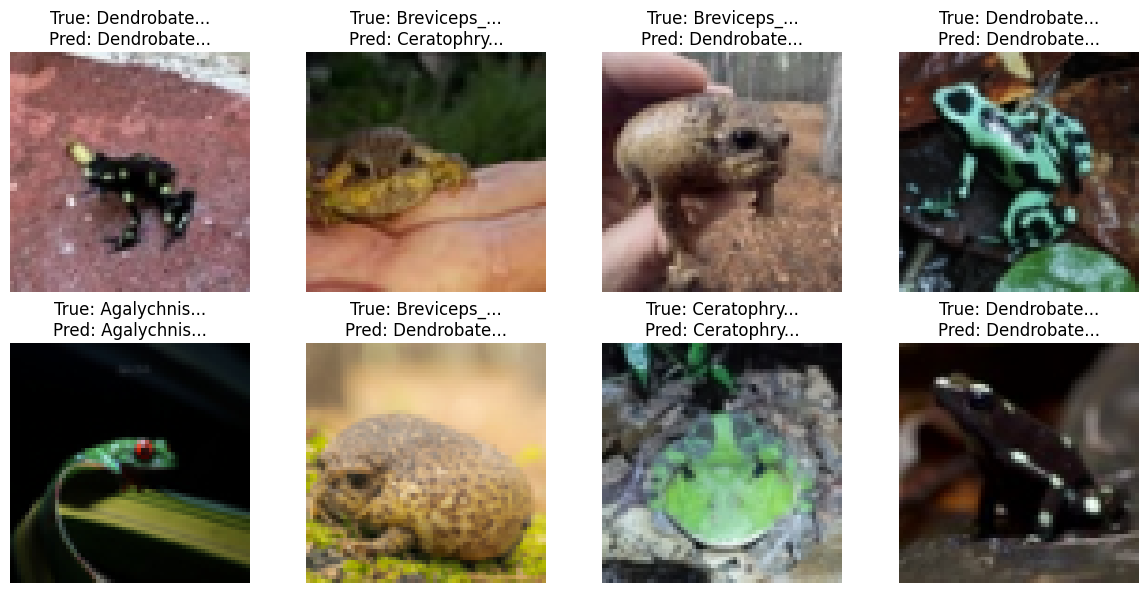

In [17]:
import matplotlib.pyplot as plt

# берём несколько изображений из test set
model.eval()
images_shown = 8

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

with torch.no_grad():
    for idx in range(images_shown):
        img, label = test_dataset[idx]
        output = model(img.unsqueeze(0))
        _, pred = torch.max(output, 1)
        
        # denormalize для отображения
        img_display = img * 0.5 + 0.5  # обратная нормализация
        img_display = img_display.permute(1, 2, 0).numpy()
        
        axes[idx].imshow(img_display)
        axes[idx].set_title(f'True: {CLASS_NAMES[label][:10]}...\nPred: {CLASS_NAMES[pred.item()][:10]}...')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Workflow

1. **Prepare dataset**
   - Run `dvc repro` to download images (if not done)
   - Images should be in `download/dataset/{class_name}/`

2. **Run cells in order**
   - Imports
   - Constants
   - Transform
   - Load Data
   - Model
   - Training
   - Save

3. **Make predictions**
   - Use `predict_image(model, 'path/to/image.jpg', CLASS_NAMES)`

### How to improve

- Low Accuracy -> incr. `EPOCHS`
- High Train Acc. + Low Val. Acc. -> incr. dropout / add regularization
- Out of memory -> reduce `BATCH_SIZE`